<a href="https://colab.research.google.com/github/LuizaRamos/TOL506M_Final_Project/blob/main/notebooks/01_task1_scratch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# TÖL506M - Introduction to Deep Neural Network
## Final Project: Wildlife Image Classification
### Task 1 - Training from Scratch

**name:** Luiza V Sampaio Ramos, **email:** lvs2@gmail.com

In this notebook, a classification model is trained from scratch, using the dataset [Animals-10](https://www.kaggle.com/datasets/alessiocorrado99/animals10) and the data split analised in the previous notebook ([00_data_exploration.ipynb](https://github.com/LuizaRamos/TOL506M_Final_Project/blob/main/notebooks/00_data_exploration.ipynb)). The training is performed independantly over different fractions of the training database (10%, 25%, 50%, 75% and 100%), and the summary of metrics and plots are shown and downloaded in a zip format.

**Observation:**

1.   The first six (6) cells of code bellow were implemented to be able to run the notebook using Google Colab mantainig it connected to the GitHub project. The rest o the code was initially wroten using DataSpell.
2.   This notebook demanded around 5 hours to ran completly, it can be interesting to break the for loop in cell 7 to run each fraction of tha training data independently.
3.   To better estimate the uncertainty three (3) notebook in total, were ran with distinct random seed. The other two notebooks are avalible at: [01_task1_scratch_2.ipynb](https://colab.research.google.com/github/LuizaRamos/TOL506M_Final_Project/blob/main/notebooks/01_task1_scratch_2.ipynb) and [01_task1_scratch_3.ipynb](https://colab.research.google.com/github/LuizaRamos/TOL506M_Final_Project/blob/main/notebooks/01_task1_scratch_3.ipynb).

In [ ]:
!rm -rf /content/TOL506M_Final_Project

In [ ]:
import os, sys, subprocess

REPO_URL = "https://github.com/LuizaRamos/TOL506M_Final_Project.git"
REPO_DIR = "/content/TOL506M_Final_Project"

# Always clone fresh in Colab
subprocess.run(["git", "clone", REPO_URL, REPO_DIR], check=True)

os.chdir(REPO_DIR)

if REPO_DIR not in sys.path:
    sys.path.insert(0, REPO_DIR)
os.environ["PYTHONPATH"] = REPO_DIR + os.pathsep + os.environ.get("PYTHONPATH", "")

In [ ]:
import sys
import os
import json
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

import torch
from torchvision import datasets, transforms

project_root = Path.cwd()
if project_root.name != "TOL506M_Final_Project":
    original = project_root
    while project_root.name != "TOL506M_Final_Project" and project_root != project_root.parent:
        project_root = project_root.parent

    if project_root.name == "TOL506M_Final_Project":
        os.chdir(project_root)
        print(f"Changed working directory from {original} to {project_root}")
    else:
        raise RuntimeError(
            "Could not locate the TOL506M_Final_Project root directory. "
            "Please run this notebook/script from within the project tree."
        )
else:
    print(f"Working directory: {project_root}")

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

# Plot styling
sns.set_style("whitegrid")
plt.rcParams.update({"figure.figsize": (12, 6), "font.size": 12})

print(f"\nPyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

Working directory: /content/TOL506M_Final_Project

PyTorch version: 2.8.0+cu126
CUDA available: True


In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("alessiocorrado99/animals10")

print(f'Dataset downloaded: {path}\n')

Using Colab cache for faster access to the 'animals10' dataset.
Dataset downloaded: /kaggle/input/animals10



In [ ]:
# Import project modules
from config import Config
from data.dataset import (WildlifeDataset, SplitIndices, stratified_split,
                          translate_names, get_data_loaders)
from tasks.task1 import train_from_scratch

data_fractions = Config.DATA_FRACTIONS
train_size = Config.TRAIN_SPLIT
val_size = Config.VAL_SPLIT
test_size = Config.TEST_SPLIT
random_seed = Config.RANDOM_SEED

data_path = Path(path) / 'raw-img'
Config.DATA_PATH = data_path

basic_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

# Download and split dataset as previously done on notebook 00_data_exploration
full_dataset = datasets.ImageFolder(root=str(data_path), transform=basic_transform)
dataset_transformed = translate_names(full_dataset)

wildlife = WildlifeDataset(str(data_path), transform=None)
train_idx_base, val_idx_fixed, test_idx_fixed = stratified_split(
    full_dataset,
    train_size=train_size,
    val_size=val_size,
    test_size=test_size,
    random_seed=random_seed
)

fixed = SplitIndices(train=train_idx_base, val=val_idx_fixed, test=test_idx_fixed)

print(f'Total images: {len(wildlife)}')
print(f'Base Train images: {len(train_idx_base)}')
print(f'Validation images: {len(val_idx_fixed)}')
print(f'Test images: {len(test_idx_fixed)}')

Total images: 26179
Base Train images: 18325
Validation images: 3927
Test images: 3927


In [ ]:
# Create output dirs if they don't exist
Config.MODELS_DIR.mkdir(parents=True, exist_ok=True)
Config.PLOTS_DIR.mkdir(parents=True, exist_ok=True)
Config.METRICS_DIR.mkdir(parents=True, exist_ok=True)


Starting training for data fraction = 10%

Training on 10 classes.
Training samples: 1832.
Validation samples: 3927.
Test samples: 3927.
Model ResNet-18 from scratch.
Parameters: 11,181,642


Validation: 100%|██████████| 62/62 [00:05<00:00, 11.15it/s]



 Epoch 1/100:
 Train Loss: 3.4697, Train Acc: 15.78%
 Val Loss: 46.9066, Val Acc: 11.84%
Saved best model (Val Acc: 11.84%) to /content/TOL506M_Final_Project/results/models/task1_scratch_best_fraction_0.10.pth.


Validation: 100%|██████████| 62/62 [00:05<00:00, 11.82it/s]



 Epoch 2/100:
 Train Loss: 2.2500, Train Acc: 18.78%
 Val Loss: 2.2892, Val Acc: 19.23%
Saved best model (Val Acc: 19.23%) to /content/TOL506M_Final_Project/results/models/task1_scratch_best_fraction_0.10.pth.


...

Validation: 100%|██████████| 62/62 [00:05<00:00, 11.40it/s]



 Epoch 99/100:
 Train Loss: 0.8597, Train Acc: 70.63%
 Val Loss: 1.2917, Val Acc: 58.31%


Validation: 100%|██████████| 62/62 [00:05<00:00, 11.57it/s]


 Epoch 100/100:
 Train Loss: 0.8567, Train Acc: 69.65%
 Val Loss: 1.3066, Val Acc: 58.19%
Training completed in 1094.31 seconds.



 Test Results: 
 Accuracy: 58.95%
 Precision: 58.77%
 Recall: 58.95%
 F1-score: 58.22%


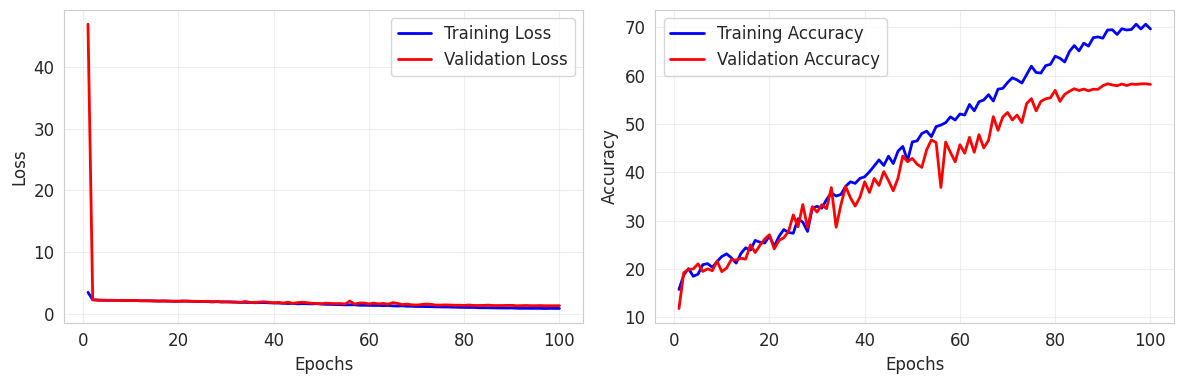

Saved metrics to /content/TOL506M_Final_Project/results/metrics/task1_scratch_results_0.10.json

Starting training for data fraction = 25%

Training on 10 classes.
Training samples: 4581.
Validation samples: 3927.
Test samples: 3927.
Model ResNet-18 from scratch.
Parameters: 11,181,642


Validation: 100%|██████████| 62/62 [00:05<00:00, 10.93it/s]



 Epoch 1/100:
 Train Loss: 2.5385, Train Acc: 17.55%
 Val Loss: 2.1990, Val Acc: 18.72%
Saved best model (Val Acc: 18.72%) to /content/TOL506M_Final_Project/results/models/task1_scratch_best_fraction_0.25.pth.


Validation: 100%|██████████| 62/62 [00:05<00:00, 11.94it/s]



 Epoch 2/100:
 Train Loss: 2.1853, Train Acc: 20.43%
 Val Loss: 2.1998, Val Acc: 21.21%
Saved best model (Val Acc: 21.21%) to /content/TOL506M_Final_Project/results/models/task1_scratch_best_fraction_0.25.pth.


...

Validation: 100%|██████████| 62/62 [00:05<00:00, 12.10it/s]



 Epoch 99/100:
 Train Loss: 0.1197, Train Acc: 96.92%
 Val Loss: 0.8568, Val Acc: 76.47%


Validation: 100%|██████████| 62/62 [00:05<00:00, 11.86it/s]


 Epoch 100/100:
 Train Loss: 0.1147, Train Acc: 97.10%
 Val Loss: 0.8514, Val Acc: 76.47%
Training completed in 1845.39 seconds.



 Test Results: 
 Accuracy: 76.34%
 Precision: 76.69%
 Recall: 76.34%
 F1-score: 76.35%


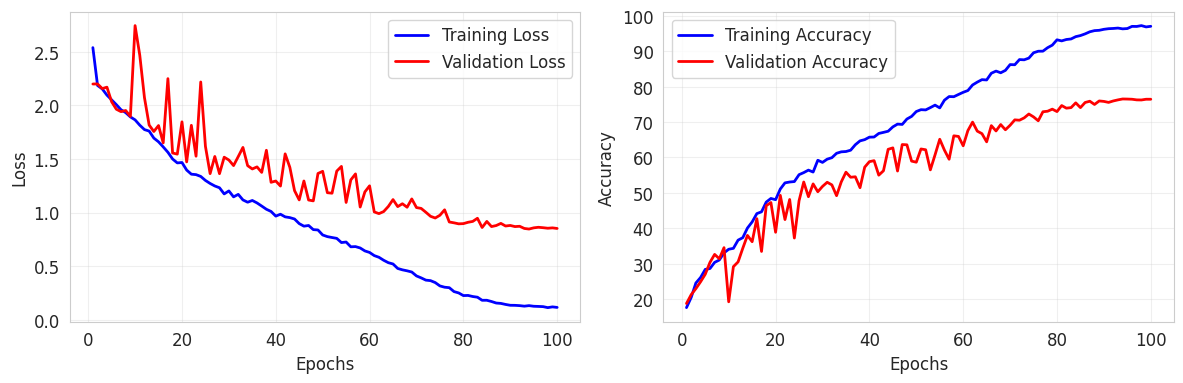

Saved metrics to /content/TOL506M_Final_Project/results/metrics/task1_scratch_results_0.25.json

Starting training for data fraction = 50%

Training on 10 classes.
Training samples: 9162.
Validation samples: 3927.
Test samples: 3927.
Model ResNet-18 from scratch.
Parameters: 11,181,642


Validation: 100%|██████████| 62/62 [00:05<00:00, 11.64it/s]



 Epoch 1/100:
 Train Loss: 2.4553, Train Acc: 20.27%
 Val Loss: 2.1996, Val Acc: 20.37%
Saved best model (Val Acc: 20.37%) to /content/TOL506M_Final_Project/results/models/task1_scratch_best_fraction_0.50.pth.


Validation: 100%|██████████| 62/62 [00:05<00:00, 11.86it/s]



 Epoch 2/100:
 Train Loss: 2.1388, Train Acc: 23.88%
 Val Loss: 2.1707, Val Acc: 22.71%
Saved best model (Val Acc: 22.71%) to /content/TOL506M_Final_Project/results/models/task1_scratch_best_fraction_0.50.pth.


...

Validation: 100%|██████████| 62/62 [00:05<00:00, 11.64it/s]



 Epoch 96/100:
 Train Loss: 0.0442, Train Acc: 99.18%
 Val Loss: 0.5562, Val Acc: 84.54%


Validation: 100%|██████████| 62/62 [00:05<00:00, 11.95it/s]


 Epoch 97/100:
 Train Loss: 0.0461, Train Acc: 99.01%
 Val Loss: 0.5538, Val Acc: 84.57%
Early stopping triggered at epoch 97.
Training completed in 3001.57 seconds.



 Test Results: 
 Accuracy: 84.82%
 Precision: 84.96%
 Recall: 84.82%
 F1-score: 84.79%


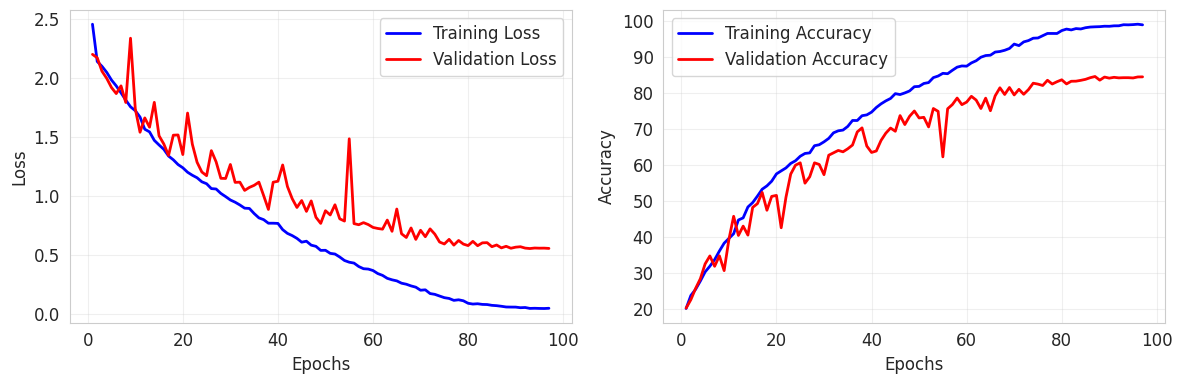

Saved metrics to /content/TOL506M_Final_Project/results/metrics/task1_scratch_results_0.50.json

Starting training for data fraction = 75%

Training on 10 classes.
Training samples: 13743.
Validation samples: 3927.
Test samples: 3927.
Model ResNet-18 from scratch.
Parameters: 11,181,642


Validation: 100%|██████████| 62/62 [00:05<00:00, 11.35it/s]



 Epoch 1/100:
 Train Loss: 2.3212, Train Acc: 20.40%
 Val Loss: 2.1511, Val Acc: 22.74%
Saved best model (Val Acc: 22.74%) to /content/TOL506M_Final_Project/results/models/task1_scratch_best_fraction_0.75.pth.


Validation: 100%|██████████| 62/62 [00:05<00:00, 11.56it/s]



 Epoch 2/100:
 Train Loss: 2.0436, Train Acc: 27.80%
 Val Loss: 1.9836, Val Acc: 28.93%
Saved best model (Val Acc: 28.93%) to /content/TOL506M_Final_Project/results/models/task1_scratch_best_fraction_0.75.pth.


...

Validation: 100%|██████████| 62/62 [00:05<00:00, 12.13it/s]



 Epoch 57/100:
 Train Loss: 0.2156, Train Acc: 93.04%
 Val Loss: 0.6403, Val Acc: 80.83%


Validation: 100%|██████████| 62/62 [00:05<00:00, 11.76it/s]


 Epoch 58/100:
 Train Loss: 0.1990, Train Acc: 93.32%
 Val Loss: 0.5719, Val Acc: 82.56%
Early stopping triggered at epoch 58.
Training completed in 2516.68 seconds.



 Test Results: 
 Accuracy: 82.79%
 Precision: 84.18%
 Recall: 82.79%
 F1-score: 82.70%


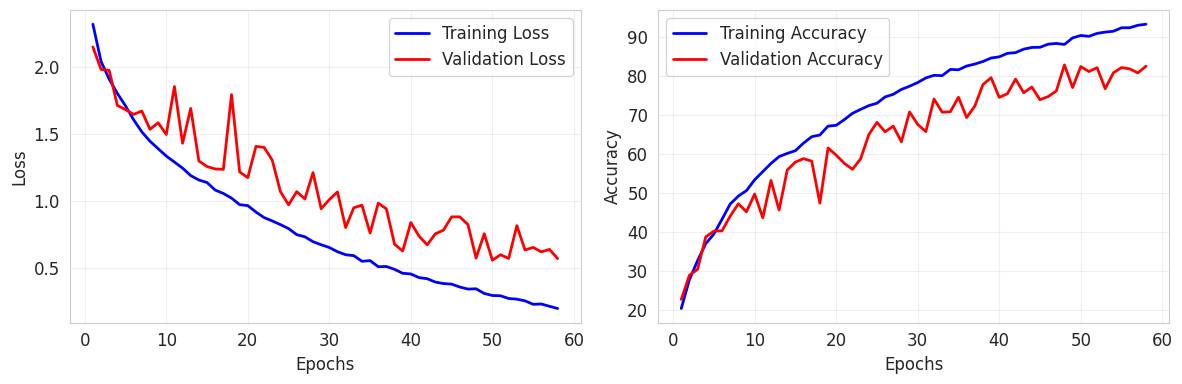

Saved metrics to /content/TOL506M_Final_Project/results/metrics/task1_scratch_results_0.75.json

Starting training for data fraction = 100%

Training on 10 classes.
Training samples: 18325.
Validation samples: 3927.
Test samples: 3927.
Model ResNet-18 from scratch.
Parameters: 11,181,642


Validation: 100%|██████████| 62/62 [00:05<00:00, 11.51it/s]



 Epoch 1/100:
 Train Loss: 2.2545, Train Acc: 21.44%
 Val Loss: 2.2717, Val Acc: 24.75%
Saved best model (Val Acc: 24.75%) to /content/TOL506M_Final_Project/results/models/task1_scratch_best_fraction_1.00.pth.


Validation: 100%|██████████| 62/62 [00:05<00:00, 11.33it/s]



 Epoch 2/100:
 Train Loss: 2.0598, Train Acc: 26.06%
 Val Loss: 1.9777, Val Acc: 31.12%
Saved best model (Val Acc: 31.12%) to /content/TOL506M_Final_Project/results/models/task1_scratch_best_fraction_1.00.pth.


...

Validation: 100%|██████████| 62/62 [00:05<00:00, 12.24it/s]



 Epoch 99/100:
 Train Loss: 0.0097, Train Acc: 99.87%
 Val Loss: 0.3328, Val Acc: 91.27%


Validation: 100%|██████████| 62/62 [00:05<00:00, 11.80it/s]


 Epoch 100/100:
 Train Loss: 0.0082, Train Acc: 99.90%
 Val Loss: 0.3277, Val Acc: 90.91%
Training completed in 5562.94 seconds.



 Test Results: 
 Accuracy: 90.99%
 Precision: 91.04%
 Recall: 90.99%
 F1-score: 90.97%


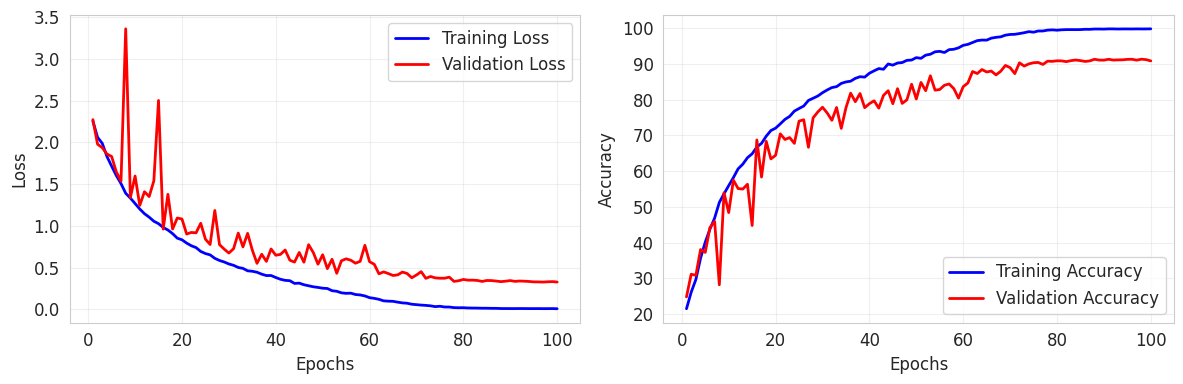

Saved metrics to /content/TOL506M_Final_Project/results/metrics/task1_scratch_results_1.00.json

Finished training for all fractions.


In [ ]:
# Task 1: Train ResNet-18 from scratch for each data fraction
all_results = []

for frac in data_fractions:
  print(f"\nStarting training for data fraction = {frac*100:.0f}%\n")

  train_loader, val_loader, test_loader, num_classes = get_data_loaders(
        data_path=str(Config.DATA_PATH),
        batch_size=Config.BATCH_SIZE,
        num_workers=Config.NUM_WORKERS,
        train_split=Config.TRAIN_SPLIT,
        val_split=Config.VAL_SPLIT,
        test_split=Config.TEST_SPLIT,
        use_augmentation=Config.USE_AUGMENTATION,
        random_seed=Config.RANDOM_SEED,
        data_fraction=frac,
        fixed_indices=fixed,
        save_processed_root=str(Config.PROCESSED_DIR),
  )

  result = train_from_scratch(
        config=Config,
        data_fraction=frac,
        version_RestNet=18,
        save_model=True,
        train_loader=train_loader,
        val_loader=val_loader,
        test_loader=test_loader
  )

  all_results.append(result)

print("\nFinished training for all fractions.")

In [ ]:
# Save combined summary JSON
summary_path = Config.METRICS_DIR / "task1_scratch_all_fractions_summary.json"

with open(summary_path, "w") as f:
    json.dump(all_results, f, indent=4)

print(f"Saved combined summary to {summary_path}")

Saved combined summary to /content/TOL506M_Final_Project/results/metrics/task1_scratch_all_fractions_summary.json



Learning curves for fraction = 10%


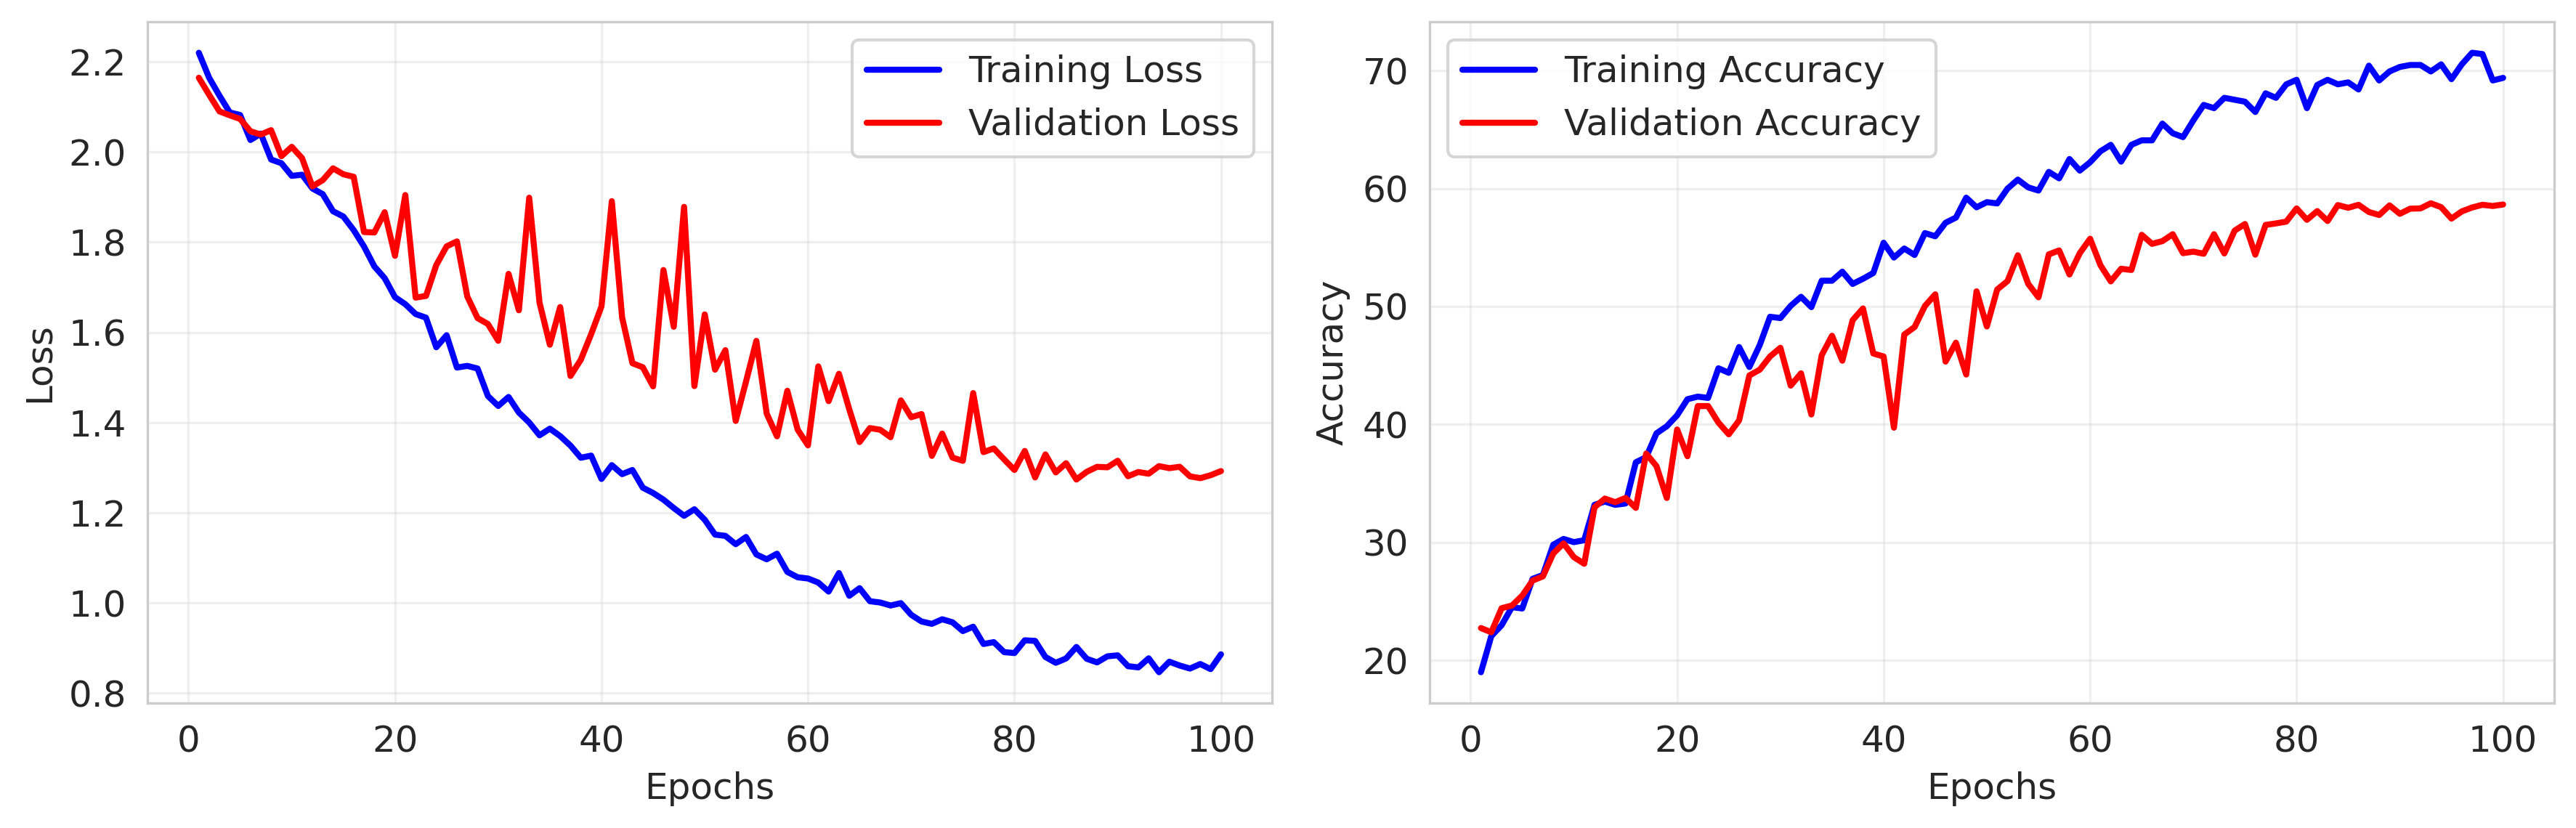


Learning curves for fraction = 25%


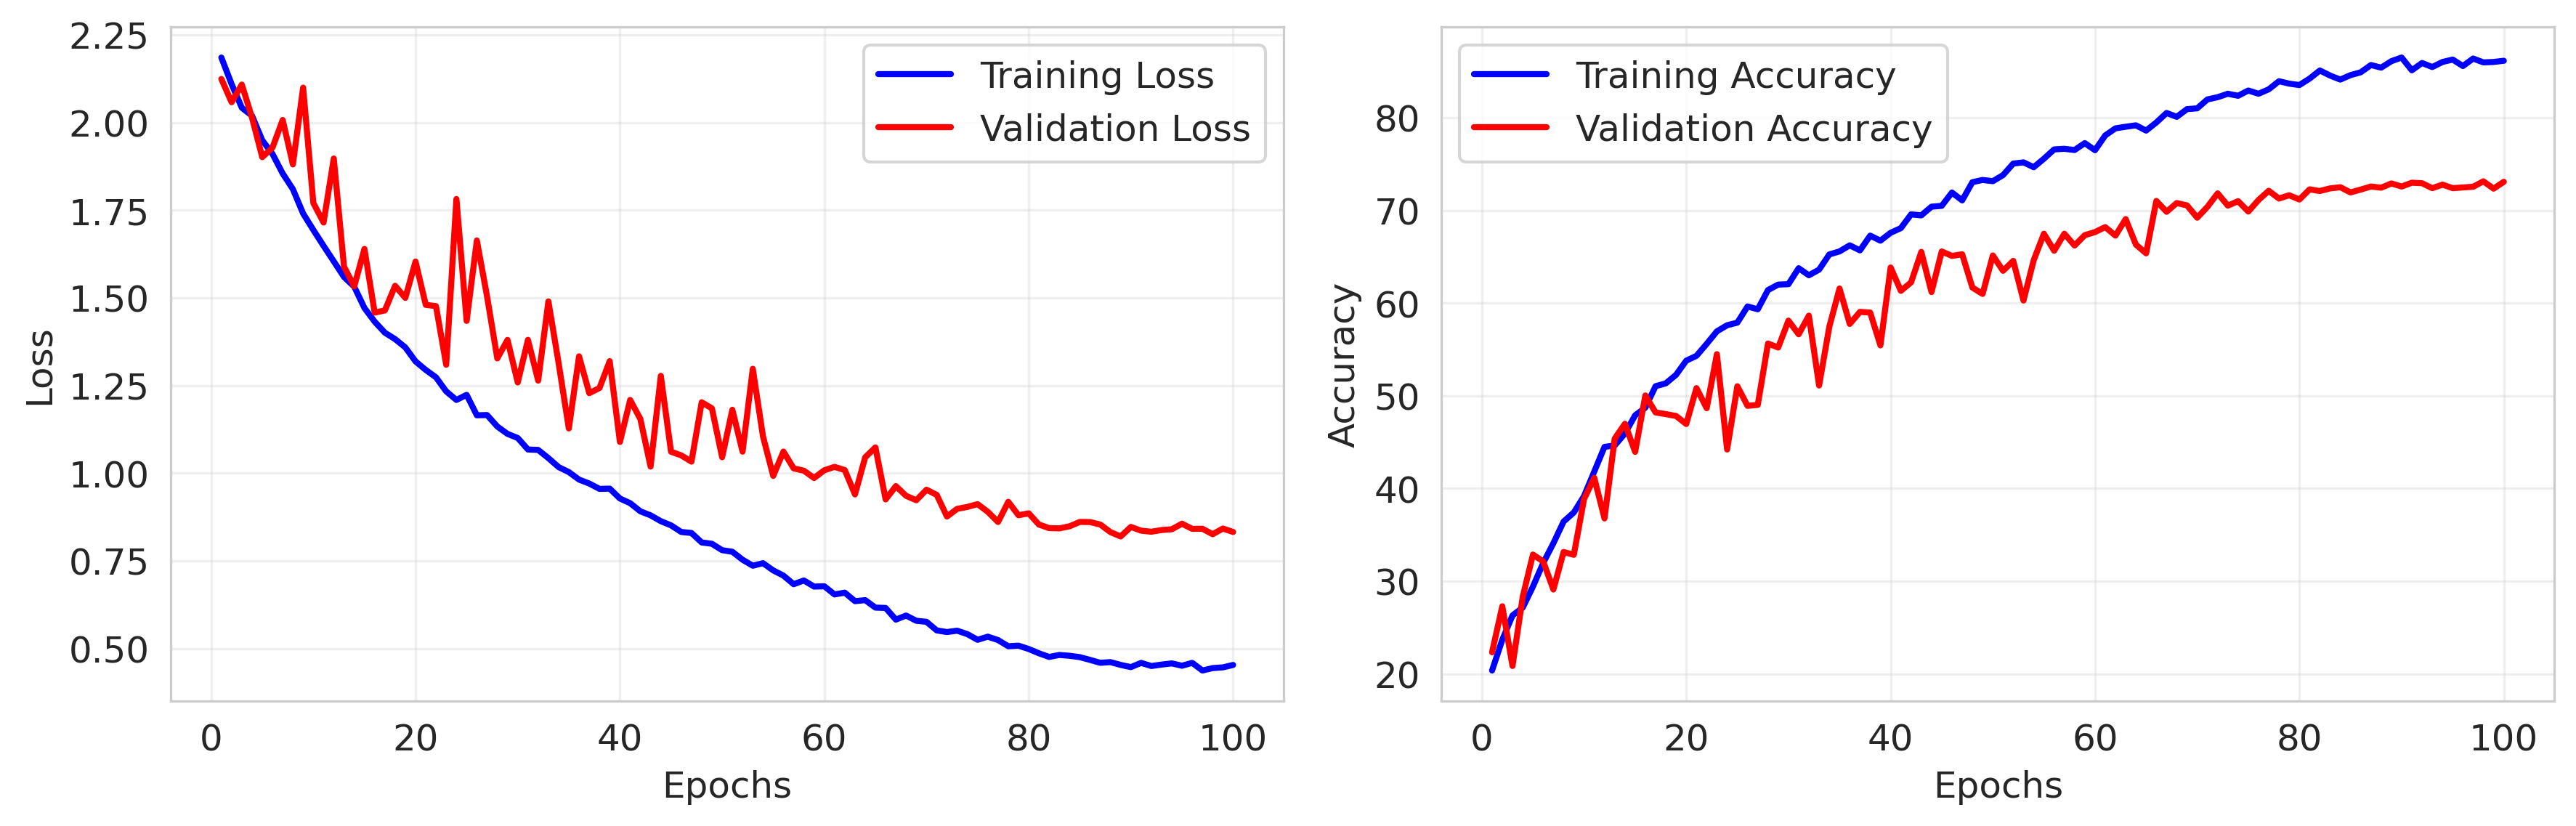


Learning curves for fraction = 50%


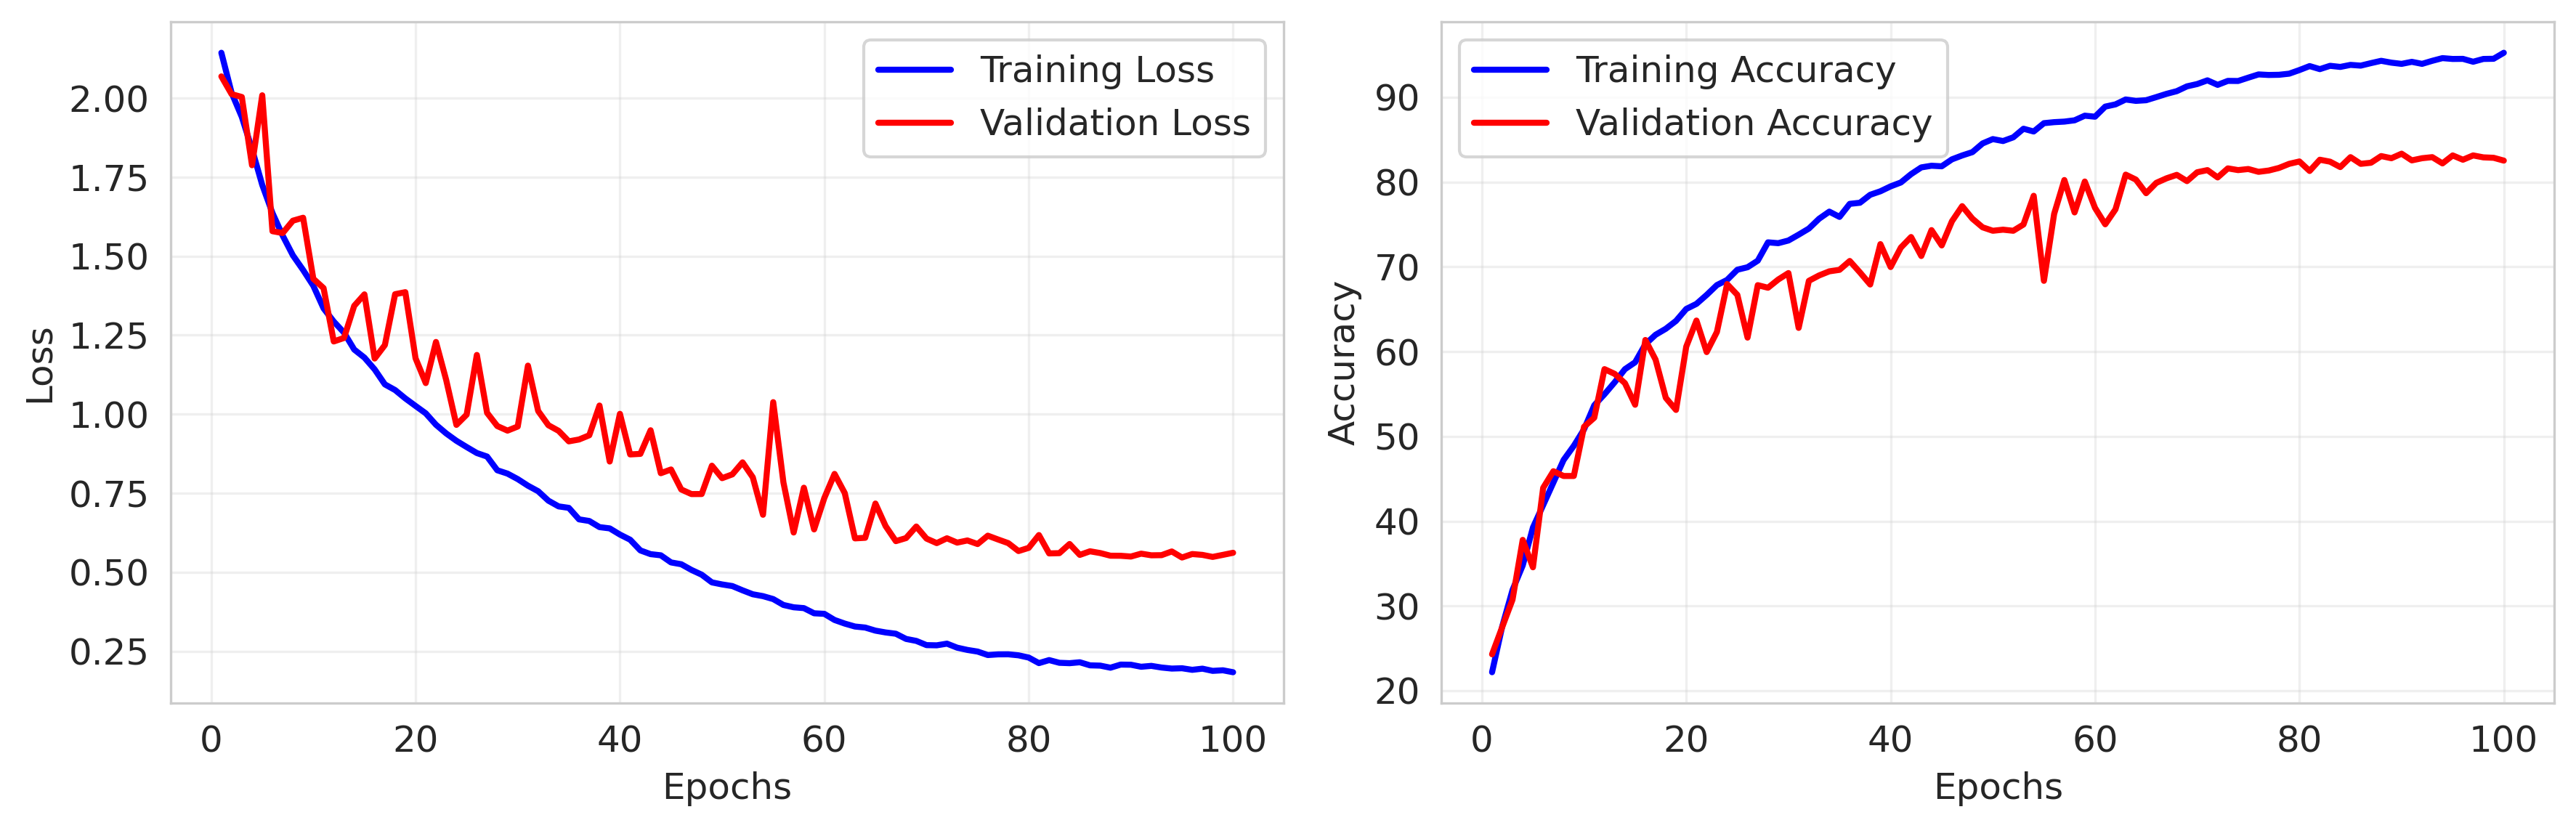


Learning curves for fraction = 75%


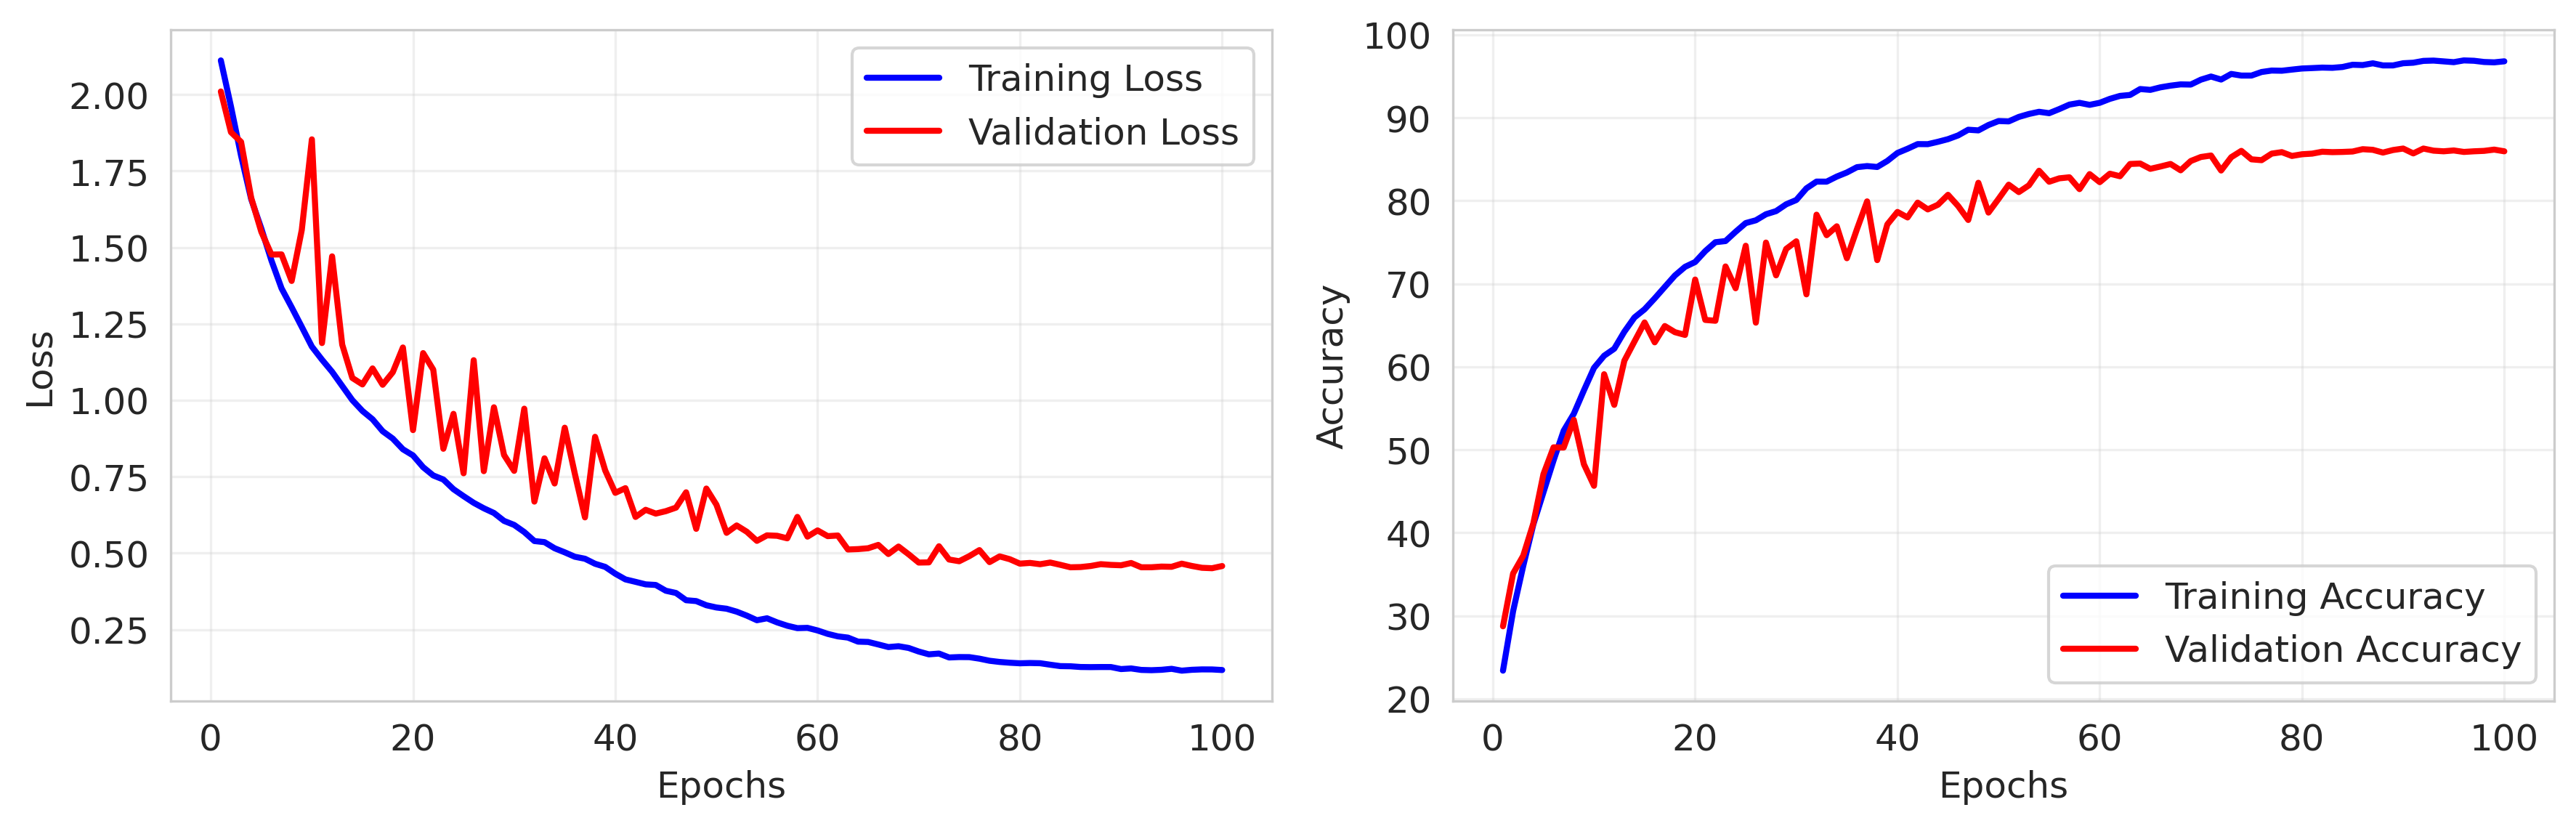


Learning curves for fraction = 100%


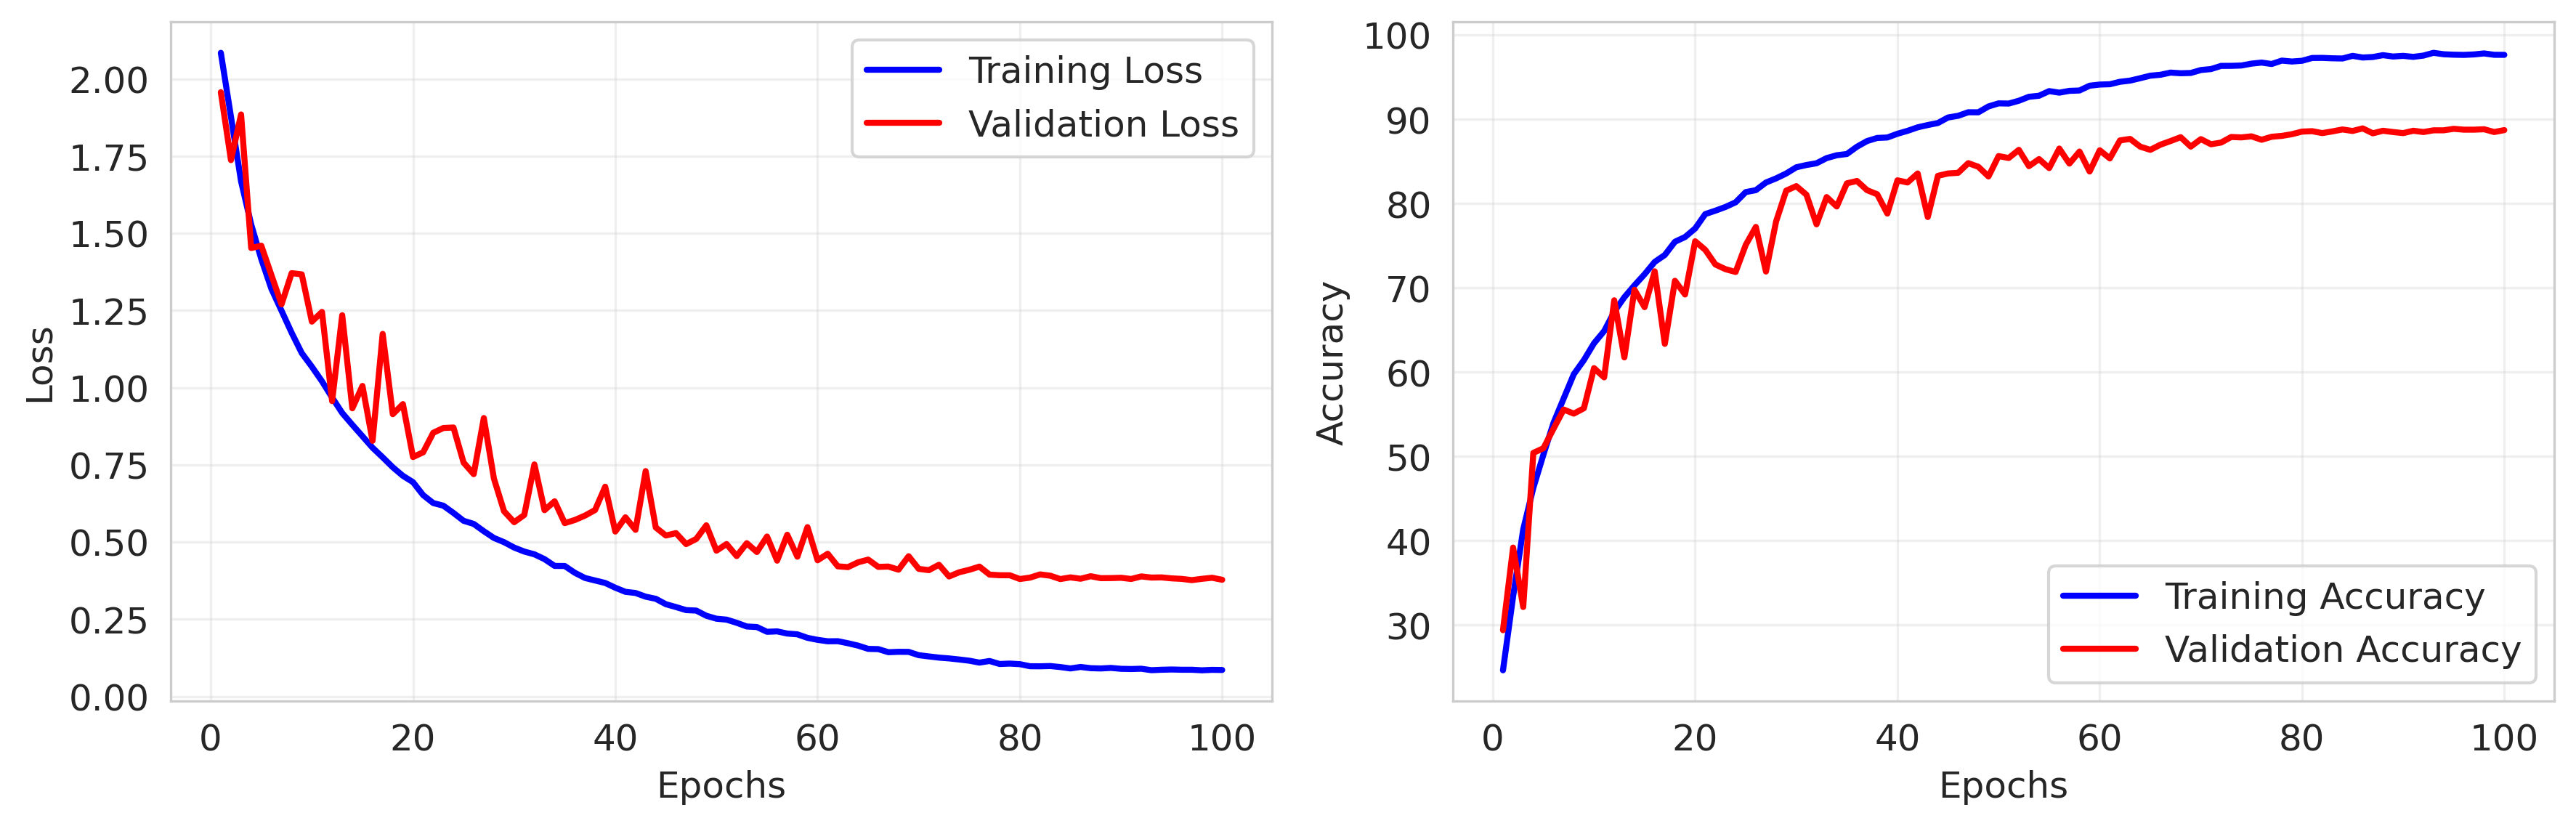

In [ ]:
from IPython.display import Image, display

for frac in data_fractions:
    plot_path = Config.PLOTS_DIR / f"task1_scratch_learning_curves_{frac:.2f}.png"
    if plot_path.exists():
        print(f"\nLearning curves for fraction = {frac*100:.0f}%")
        display(Image(filename=str(plot_path)))
    else:
        print(f"Plot not found for fraction {frac:.2f}: {plot_path}")

In [ ]:
# Save combined summary JSON - NOT NECESSARY
summary_path = Config.METRICS_DIR / "task3_zero_shot_classification_summary.json"

with open(summary_path, "w") as f:
    json.dump(result, f, indent=4)

print(f"Saved combined summary to {summary_path}")

Saved combined summary to /content/TOL506M_Final_Project/results/metrics/task3_zero_shot_classification_summary.json


In [ ]:
!zip -r results_task1.zip /content/TOL506M_Final_Project/results/

  adding: content/TOL506M_Final_Project/results/ (stored 0%)
  adding: content/TOL506M_Final_Project/results/metrics/ (stored 0%)
  adding: content/TOL506M_Final_Project/results/metrics/task3_zero_shot_classification_summary.json (deflated 65%)
  adding: content/TOL506M_Final_Project/results/metrics/task1_scratch_results_1.00.json (deflated 65%)
  adding: content/TOL506M_Final_Project/results/metrics/task1_scratch_results_0.10.json (deflated 66%)
  adding: content/TOL506M_Final_Project/results/metrics/task1_scratch_results_0.25.json (deflated 63%)
  adding: content/TOL506M_Final_Project/results/metrics/task1_scratch_results_0.50.json (deflated 63%)
  adding: content/TOL506M_Final_Project/results/metrics/task1_scratch_results_0.75.json (deflated 61%)
  adding: content/TOL506M_Final_Project/results/metrics/.ipynb_checkpoints/ (stored 0%)
  adding: content/TOL506M_Final_Project/results/plots/ (stored 0%)
  adding: content/TOL506M_Final_Project/results/plots/task1_scratch_learning_curves_0

In [ ]:
from google.colab import files
files.download("results_task1.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>